# Project 6 — Plant 2 Complete Week-1 Notebook & AI/ML Handover
## Generation + Weather + Open-Meteo + Final Member-4 Integration

### Purpose
This is the **single complete Plant 2 notebook** for handover to the Plant 2 AI/ML team member.

It combines, in one continuous workflow:
1. Plant 2 generation cleaning, validation and EDA
2. Plant 2 weather-sensor cleaning, validation and EDA
3. Plant 2 Open-Meteo loading, mapping and weather/solar EDA
4. Generation–weather relationships
5. Member-4 final integration and validation
6. Final AI/ML-ready datasets at inverter-level 15-minute, plant-level 15-minute, and hourly resolution

### AI/ML handoff recommendation
- **Primary Week-1 baseline:** `plant2_ai_ml_handoff_hourly.csv`
- **15-minute plant forecasting:** `plant2_ai_ml_handoff_15min_plantlevel.csv`
- **Advanced inverter-level modeling:** `plant2_ai_ml_handoff_15min.csv`

The AI/ML member can continue modelling **in this same notebook after the final handoff section**.


In [30]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Dynamic directory resolution for local IDE (root or notebooks/) and Google Colab (/content)
def resolve_dir(candidates, default):
    for c in candidates:
        if c.exists():
            return c
    return default

BASE_DIR = resolve_dir([
    Path("data/raw"),
    Path("../data/raw"),
    Path("/content/data/raw"),
    Path("/content"),
    Path("/mnt/data")
], default=Path("data/raw"))

OUTPUT_DIR = resolve_dir([
    Path("data/processed"),
    Path("../data/processed"),
    Path("/content/data/processed")
], default=Path("data/processed"))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def resolve_file(names):
    for name in names:
        p = BASE_DIR / name
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find any of: {names} in {BASE_DIR}")

GEN_FILE = resolve_file(["Plant_2_Generation_Data.csv", "Plant_2_Generation_Data(1).csv", "Plant_2_Generation_Data(2).csv"])
WEATHER_FILE = resolve_file(["Plant_2_Weather_Sensor_Data.csv", "Plant_2_Weather_Sensor_Data(1).csv"])

# Correct project mapping:
# Plant 2 -> Open-Meteo 14.38N, 77.50E, 491m
OPENMETEO_FILE = resolve_file(["open-meteo-14.38N77.50E491m.csv"])

print("Generation:", GEN_FILE)
print("Weather:", WEATHER_FILE)
print("Open-Meteo:", OPENMETEO_FILE)
print("Output:", OUTPUT_DIR)


Generation: /content/Plant_2_Generation_Data.csv
Weather: /content/Plant_2_Weather_Sensor_Data.csv
Open-Meteo: /content/open-meteo-14.38N77.50E491m.csv
Output: /content/plant2_complete_week1_ai_ml_handoff


## 1. Load Plant 2 source datasets

In [31]:
generation_raw = pd.read_csv(GEN_FILE)
weather_raw = pd.read_csv(WEATHER_FILE)
openmeteo_raw = pd.read_csv(OPENMETEO_FILE, skiprows=3)

print("Generation shape:", generation_raw.shape)
print("Weather shape:", weather_raw.shape)
print("Open-Meteo shape:", openmeteo_raw.shape)

display(generation_raw.head())
display(weather_raw.head())
display(openmeteo_raw.head())


Generation shape: (67698, 7)
Weather shape: (3259, 6)
Open-Meteo shape: (816, 13)


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15 00:00:00,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15 00:00:00,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09
3,2020-05-15 00:00:00,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06
4,2020-05-15 00:00:00,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4136001,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,4136001,iq8k7ZNt4Mwm3w0,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,4136001,iq8k7ZNt4Mwm3w0,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,4136001,iq8k7ZNt4Mwm3w0,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,4136001,iq8k7ZNt4Mwm3w0,26.596148,25.088210,0.0


,time,temperature_2m (°C),relative_humidity_2m (%),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),rain (mm),shortwave_radiation (W/m²),direct_radiation (W/m²),diffuse_radiation (W/m²),direct_normal_irradiance (W/m²),wind_speed_10m (km/h)
0,2020-05-15T00:00,30.0,49,15,0,11,6,0.0,0.0,0.0,0.0,0.0,10.6
1,2020-05-15T01:00,29.3,52,16,0,7,10,0.0,0.0,0.0,0.0,0.0,7.1
2,2020-05-15T02:00,28.6,55,48,0,8,44,0.0,0.0,0.0,0.0,0.0,6.6
3,2020-05-15T03:00,28.0,56,79,0,6,78,0.0,0.0,0.0,0.0,0.0,5.6
4,2020-05-15T04:00,27.4,56,61,0,4,60,0.0,0.0,0.0,0.0,0.0,3.9


## 2. Plant 2 generation — cleaning and quality checks

In [32]:
generation = generation_raw.copy()
generation["DATE_TIME"] = pd.to_datetime(generation["DATE_TIME"], errors="coerce")

for col in ["DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]:
    generation[col] = pd.to_numeric(generation[col], errors="coerce")

print("Missing values:")
display(generation.isna().sum().to_frame("missing"))
print("Exact duplicate rows:", generation.duplicated().sum())
print("Invalid timestamps:", generation["DATE_TIME"].isna().sum())
print("Negative values:")
display((generation[["DC_POWER","AC_POWER","DAILY_YIELD","TOTAL_YIELD"]] < 0).sum().to_frame("negative_count"))
print("Date range:", generation["DATE_TIME"].min(), "to", generation["DATE_TIME"].max())
print("Unique inverters:", generation["SOURCE_KEY"].nunique())


Missing values:


,missing
DATE_TIME,0
PLANT_ID,0
SOURCE_KEY,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,0


Exact duplicate rows: 0
Invalid timestamps: 0
Negative values:


,negative_count
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,0


Date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Unique inverters: 22


### Generation timestamp and inverter coverage

In [33]:
unique_generation_times = (
    generation[["DATE_TIME"]].drop_duplicates().sort_values("DATE_TIME").reset_index(drop=True)
)
generation_intervals_min = (
    unique_generation_times["DATE_TIME"].diff().dt.total_seconds().div(60).dropna()
)

print("Unique generation timestamps:", len(unique_generation_times))
print("Expected regular interval: 15 minutes")
display(generation_intervals_min.value_counts().sort_index())

inverter_coverage = generation.groupby("DATE_TIME")["SOURCE_KEY"].nunique().rename("inverter_count")
print("Inverter availability summary:")
display(inverter_coverage.describe())
print("Inverter record counts:")
display(generation["SOURCE_KEY"].value_counts().sort_index().to_frame("rows"))


Unique generation timestamps: 3259
Expected regular interval: 15 minutes


,count
DATE_TIME,
15.0,3253
30.0,5


Inverter availability summary:


,inverter_count
count,3259.00000
mean,20.77263
std,2.14073
min,12.00000
25%,18.00000
50%,22.00000
75%,22.00000
max,22.00000


Inverter record counts:


,rows
SOURCE_KEY,
4UPUqMRk7TRMgml,3195
81aHJ1q11NBPMrL,3259
9kRcWv60rDACzjR,3259
Et9kgGMDl729KT4,3195
IQ2d7wF4YD8zU1Q,2355
LYwnQax7tkwH5Cb,3259
LlT2YUhhzqhg5Sw,3259
Mx2yZCDsyf6DPfv,3195
NgDl19wMapZy17u,2355


## 3. Plant 2 TOTAL_YIELD anomaly investigation

In [34]:
TOTAL_YIELD_ANOMALY_THRESHOLD = 1_000_000_000
generation["TOTAL_YIELD_ANOMALY"] = generation["TOTAL_YIELD"] > TOTAL_YIELD_ANOMALY_THRESHOLD
anomaly_rows = generation[generation["TOTAL_YIELD_ANOMALY"]].copy()

print("Rows flagged:", len(anomaly_rows))
print("Affected inverters:", anomaly_rows["SOURCE_KEY"].nunique())

display(
    anomaly_rows.groupby("SOURCE_KEY")
    .agg(
        anomaly_rows=("TOTAL_YIELD_ANOMALY","sum"),
        min_total_yield=("TOTAL_YIELD","min"),
        max_total_yield=("TOTAL_YIELD","max")
    )
    .sort_values("anomaly_rows", ascending=False)
)

display(anomaly_rows[["DATE_TIME","SOURCE_KEY","TOTAL_YIELD","TOTAL_YIELD_ANOMALY"]].head(10))


Rows flagged: 22296
Affected inverters: 7


,anomaly_rows,min_total_yield,max_total_yield
SOURCE_KEY,,,
LYwnQax7tkwH5Cb,3234,1.077032e+09,1.795116e+09
oZZkBaNadn6DNKz,3234,1.024926e+09,1.708288e+09
V94E5Ben1TlhnDV,3229,1.008730e+09,1.412293e+09
PeE6FRyGXUgsRhN,3222,1.059510e+09,1.348549e+09
9kRcWv60rDACzjR,3218,1.049014e+09,2.247916e+09
oZ35aAeoifZaQzV,3167,1.067210e+09,1.660189e+09
81aHJ1q11NBPMrL,2992,1.041739e+09,1.215486e+09


,DATE_TIME,SOURCE_KEY,TOTAL_YIELD,TOTAL_YIELD_ANOMALY
1,2020-05-15 00:00:00,81aHJ1q11NBPMrL,1.215279e+09,True
2,2020-05-15 00:00:00,9kRcWv60rDACzjR,2.247720e+09,True
5,2020-05-15 00:00:00,LYwnQax7tkwH5Cb,1.794959e+09,True
9,2020-05-15 00:00:00,PeE6FRyGXUgsRhN,1.348351e+09,True
12,2020-05-15 00:00:00,V94E5Ben1TlhnDV,1.412083e+09,True
15,2020-05-15 00:00:00,oZ35aAeoifZaQzV,1.659965e+09,True
16,2020-05-15 00:00:00,oZZkBaNadn6DNKz,1.708083e+09,True
23,2020-05-15 00:15:00,81aHJ1q11NBPMrL,1.215279e+09,True
24,2020-05-15 00:15:00,9kRcWv60rDACzjR,2.247720e+09,True
27,2020-05-15 00:15:00,LYwnQax7tkwH5Cb,1.794959e+09,True


**Decision:** `TOTAL_YIELD` is preserved and explicitly flagged for traceability. It is **not used as the primary forecasting target** and is excluded from plant-level generation aggregation where the anomalous scale could distort the analysis. `AC_POWER`, `DC_POWER`, and `DAILY_YIELD` remain available.

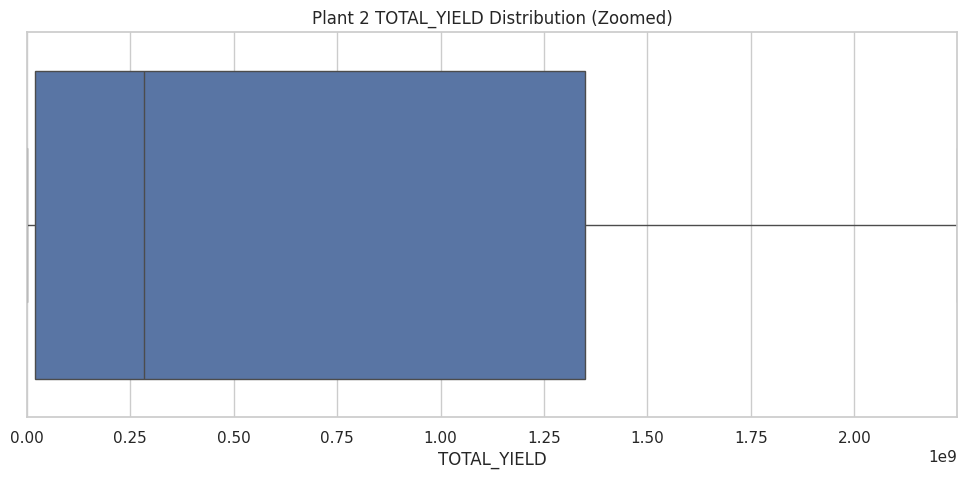

In [35]:
plt.figure(figsize=(12,5))
sns.boxplot(x=generation["TOTAL_YIELD"])
plt.xlim(0, generation["TOTAL_YIELD"].quantile(0.995))
plt.title("Plant 2 TOTAL_YIELD Distribution (Zoomed)")
plt.xlabel("TOTAL_YIELD")
plt.show()


## 4. Plant 2 inverter-level generation analysis

In [36]:
generation["DATE"] = generation["DATE_TIME"].dt.date
generation["HOUR"] = generation["DATE_TIME"].dt.hour
generation["TIME"] = generation["DATE_TIME"].dt.time

inverter_summary = (
    generation.groupby("SOURCE_KEY")
    .agg(
        records=("SOURCE_KEY","size"),
        avg_dc_power=("DC_POWER","mean"),
        max_dc_power=("DC_POWER","max"),
        avg_ac_power=("AC_POWER","mean"),
        max_ac_power=("AC_POWER","max"),
        avg_daily_yield=("DAILY_YIELD","mean")
    ).reset_index()
)
display(inverter_summary)


,SOURCE_KEY,records,avg_dc_power,max_dc_power,avg_ac_power,max_ac_power,avg_daily_yield
0,4UPUqMRk7TRMgml,3195,277.760524,1419.840000,271.576886,1384.346667,4143.422728
1,81aHJ1q11NBPMrL,3259,230.796317,1382.206667,225.728343,1347.660000,2640.050635
2,9kRcWv60rDACzjR,3259,244.653027,1396.586667,239.281783,1361.666667,2793.966510
3,Et9kgGMDl729KT4,3195,188.230376,1202.640000,184.230269,1172.653333,2356.332188
4,IQ2d7wF4YD8zU1Q,2355,285.525112,1418.928571,279.190055,1383.457143,4116.486644
5,LYwnQax7tkwH5Cb,3259,196.286078,1297.740000,192.090443,1265.666667,2559.308704
6,LlT2YUhhzqhg5Sw,3259,245.493296,1372.460000,240.110947,1338.346667,3180.399037
7,Mx2yZCDsyf6DPfv,3195,285.013230,1412.466667,278.659553,1377.153333,3809.920359
8,NgDl19wMapZy17u,2355,273.522084,1406.114286,267.485098,1370.957143,3982.965735
9,PeE6FRyGXUgsRhN,3259,248.689407,1382.086667,243.223341,1347.526667,3319.507937


### Inverter AC/DC efficiency

In [37]:
inverter_efficiency = (
    generation.groupby("SOURCE_KEY")
    .agg(dc_power=("DC_POWER","sum"), ac_power=("AC_POWER","sum"))
    .reset_index()
)
inverter_efficiency["AC_DC_EFFICIENCY"] = np.where(
    inverter_efficiency["dc_power"] > 0,
    inverter_efficiency["ac_power"] / inverter_efficiency["dc_power"],
    np.nan
)
display(inverter_efficiency.sort_values("AC_DC_EFFICIENCY", ascending=False))


,SOURCE_KEY,dc_power,ac_power,AC_DC_EFFICIENCY
11,Quc1TzYxW2pYoWX,553548.858901,542014.929794,0.979164
3,Et9kgGMDl729KT4,601396.050982,588615.708104,0.978749
5,LYwnQax7tkwH5Cb,639696.326687,626022.753183,0.978625
18,rrq4fwE8jgrTyWY,681647.365682,667002.354956,0.978515
17,q49J1IKaHRwDQnt,737061.896822,721060.844115,0.978291
6,LlT2YUhhzqhg5Sw,800062.652611,782521.577770,0.978075
2,9kRcWv60rDACzjR,797324.213511,779819.329933,0.978045
1,81aHJ1q11NBPMrL,752165.196310,735648.671081,0.978041
21,xoJJ8DcxJEcupym,785180.932443,767932.701010,0.978033
9,PeE6FRyGXUgsRhN,810478.778457,792664.868701,0.978021


## 5. Plant-level generation aggregation

In [38]:
plant_generation = (
    generation.groupby("DATE_TIME", as_index=False)
    .agg(
        DC_POWER=("DC_POWER","sum"),
        AC_POWER=("AC_POWER","sum"),
        DAILY_YIELD=("DAILY_YIELD","sum"),
        INVERTER_COUNT=("SOURCE_KEY","nunique")
    )
    .sort_values("DATE_TIME")
    .reset_index(drop=True)
)
plant_generation["DATE"] = plant_generation["DATE_TIME"].dt.date
plant_generation["HOUR"] = plant_generation["DATE_TIME"].dt.hour
plant_generation["AC_DC_EFFICIENCY"] = np.where(
    plant_generation["DC_POWER"] > 0,
    plant_generation["AC_POWER"] / plant_generation["DC_POWER"],
    np.nan
)

print("Plant-level rows:", len(plant_generation))
print("Duplicate plant timestamps:", plant_generation["DATE_TIME"].duplicated().sum())
display(plant_generation.head())


Plant-level rows: 3259
Duplicate plant timestamps: 0


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,INVERTER_COUNT,DATE,HOUR,AC_DC_EFFICIENCY
0,2020-05-15 00:00:00,0.0,0.0,48899.938095,22,2020-05-15,0,NaN
1,2020-05-15 00:15:00,0.0,0.0,28401.000000,22,2020-05-15,0,NaN
2,2020-05-15 00:30:00,0.0,0.0,28401.000000,22,2020-05-15,0,NaN
3,2020-05-15 00:45:00,0.0,0.0,28401.000000,22,2020-05-15,0,NaN
4,2020-05-15 01:00:00,0.0,0.0,26516.000000,22,2020-05-15,1,NaN


### Plant-level intraday generation curve

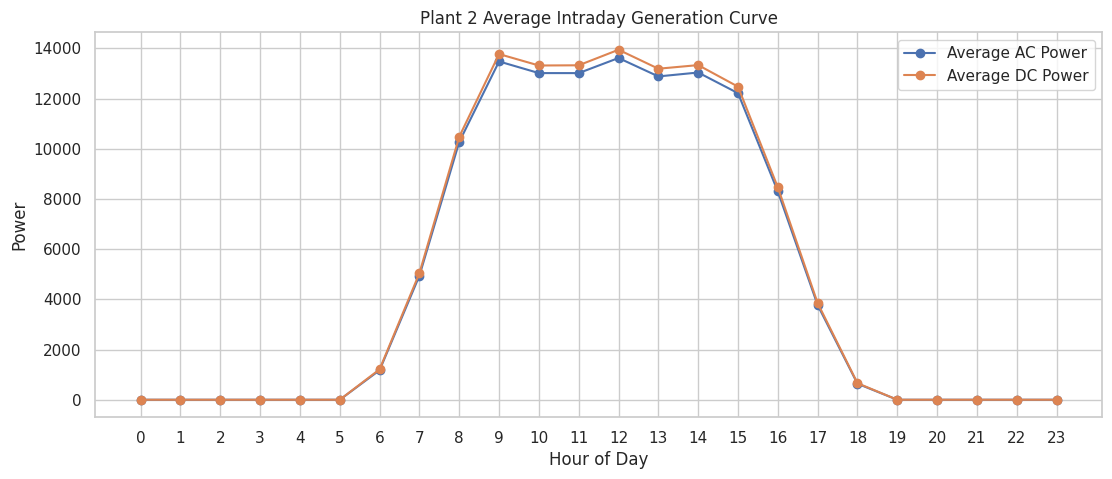

,HOUR,avg_ac_power,avg_dc_power,max_ac_power,max_dc_power
0,0,0.000000,0.000000,0.000000,0.000000
1,1,0.000000,0.000000,0.000000,0.000000
2,2,0.000000,0.000000,0.000000,0.000000
3,3,0.000000,0.000000,0.000000,0.000000
4,4,0.000000,0.000000,0.000000,0.000000
5,5,0.064055,0.066317,5.178095,5.365714
6,6,1177.247780,1211.890102,5207.334286,5309.430000
7,7,4944.444366,5043.743046,12098.332381,12344.507143
8,8,10271.418824,10478.104391,17410.006667,17790.186667
9,9,13476.934340,13771.241582,20727.341429,21194.826667


In [39]:
intraday_curve = (
    plant_generation.groupby("HOUR")
    .agg(
        avg_ac_power=("AC_POWER","mean"),
        avg_dc_power=("DC_POWER","mean"),
        max_ac_power=("AC_POWER","max"),
        max_dc_power=("DC_POWER","max")
    ).reset_index()
)

plt.figure(figsize=(13,5))
plt.plot(intraday_curve["HOUR"], intraday_curve["avg_ac_power"], marker="o", label="Average AC Power")
plt.plot(intraday_curve["HOUR"], intraday_curve["avg_dc_power"], marker="o", label="Average DC Power")
plt.title("Plant 2 Average Intraday Generation Curve")
plt.xlabel("Hour of Day")
plt.ylabel("Power")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()
display(intraday_curve)


### Daily generation and energy

In [40]:
plant_generation["INTERVAL_HOURS"] = (
    plant_generation["DATE_TIME"].shift(-1)
    .sub(plant_generation["DATE_TIME"])
    .dt.total_seconds().div(3600)
)
plant_generation.loc[plant_generation.index[-1], "INTERVAL_HOURS"] = 0.25

# Only regular/short intervals are used for interval energy.
plant_generation["INTERVAL_VALID_FOR_ENERGY"] = plant_generation["INTERVAL_HOURS"].between(0, 0.5)
plant_generation["AC_ENERGY_KWH_EST"] = np.where(
    plant_generation["INTERVAL_VALID_FOR_ENERGY"],
    plant_generation["AC_POWER"] * plant_generation["INTERVAL_HOURS"],
    np.nan
)
plant_generation["DC_ENERGY_KWH_EST"] = np.where(
    plant_generation["INTERVAL_VALID_FOR_ENERGY"],
    plant_generation["DC_POWER"] * plant_generation["INTERVAL_HOURS"],
    np.nan
)

daily_generation = (
    plant_generation.groupby("DATE")
    .agg(
        avg_ac_power=("AC_POWER","mean"),
        max_ac_power=("AC_POWER","max"),
        avg_dc_power=("DC_POWER","mean"),
        max_dc_power=("DC_POWER","max"),
        ac_energy_kwh=("AC_ENERGY_KWH_EST","sum"),
        dc_energy_kwh=("DC_ENERGY_KWH_EST","sum"),
        avg_inverter_count=("INVERTER_COUNT","mean")
    ).reset_index()
)
display(daily_generation.head())
print("Total estimated AC energy (kWh):", round(daily_generation["ac_energy_kwh"].sum(),2))


,DATE,avg_ac_power,max_ac_power,avg_dc_power,max_dc_power,ac_energy_kwh,dc_energy_kwh,avg_inverter_count
0,2020-05-15,6857.239333,19754.621905,7016.922431,20195.253810,162859.434167,166651.907738,22.000000
1,2020-05-16,5773.473547,20727.341429,5904.581667,21194.826667,138563.365119,141709.960000,22.000000
2,2020-05-17,5670.760635,19986.915238,5794.134565,20434.131905,136098.255229,139059.229551,22.000000
3,2020-05-18,5406.380888,17450.613810,5528.892470,17892.292857,129753.141310,132693.419286,22.000000
4,2020-05-19,4563.733923,17812.551905,4668.377337,18221.230000,108829.800579,111327.427138,21.263158


Total estimated AC energy (kWh): 4090278.25


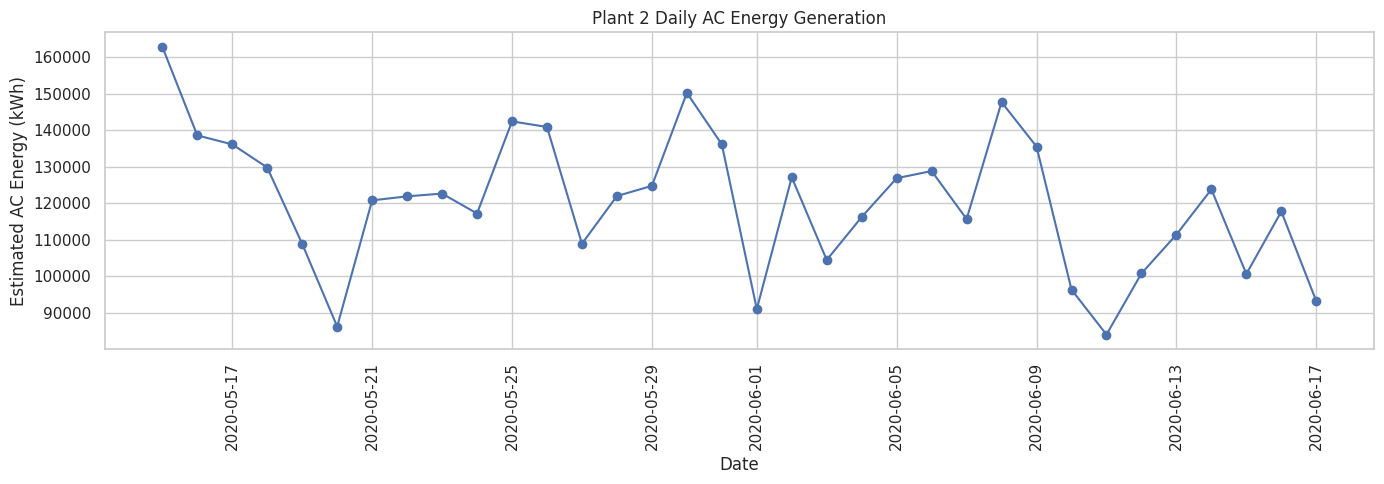

In [41]:
plt.figure(figsize=(14,5))
plt.plot(daily_generation["DATE"], daily_generation["ac_energy_kwh"], marker="o")
plt.title("Plant 2 Daily AC Energy Generation")
plt.xlabel("Date")
plt.ylabel("Estimated AC Energy (kWh)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


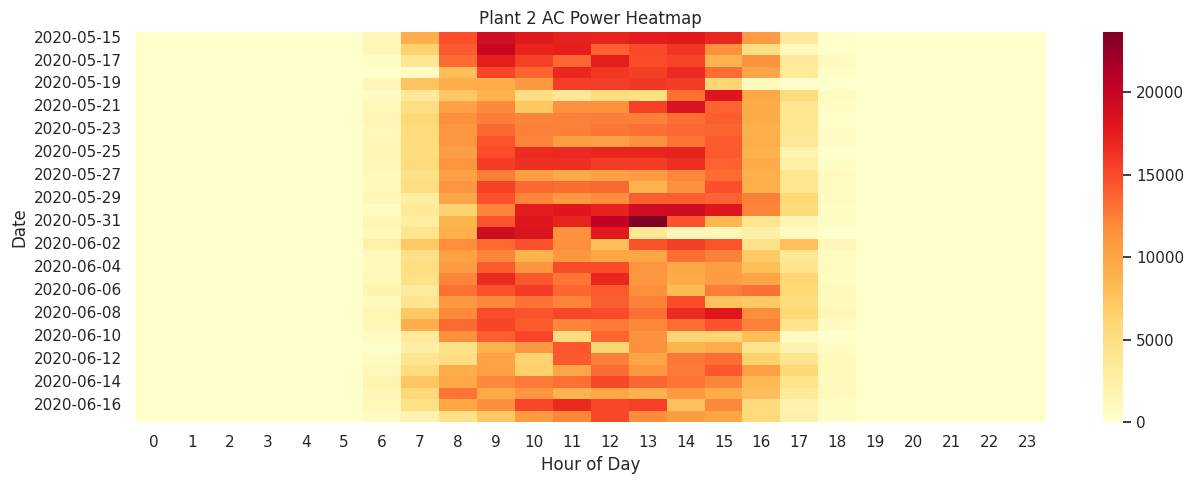

In [42]:
plt.figure(figsize=(13,5))
sns.heatmap(
    plant_generation.pivot_table(index="DATE", columns="HOUR", values="AC_POWER", aggfunc="mean"),
    cmap="YlOrRd"
)
plt.title("Plant 2 AC Power Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Date")
plt.tight_layout()
plt.show()


## 6. Plant 2 weather-sensor cleaning and quality checks

In [43]:
weather = weather_raw.copy()
weather["DATE_TIME"] = pd.to_datetime(weather["DATE_TIME"], errors="coerce")
for col in ["AMBIENT_TEMPERATURE","MODULE_TEMPERATURE","IRRADIATION"]:
    weather[col] = pd.to_numeric(weather[col], errors="coerce")

print("Missing values:")
display(weather.isna().sum().to_frame("missing"))
print("Exact duplicate rows:", weather.duplicated().sum())
print("Invalid timestamps:", weather["DATE_TIME"].isna().sum())
print("Negative weather values:")
display((weather[["AMBIENT_TEMPERATURE","MODULE_TEMPERATURE","IRRADIATION"]] < 0).sum().to_frame("negative_count"))
print("Date range:", weather["DATE_TIME"].min(), "to", weather["DATE_TIME"].max())
print("Weather SOURCE_KEY count:", weather["SOURCE_KEY"].nunique())


Missing values:


,missing
DATE_TIME,0
PLANT_ID,0
SOURCE_KEY,0
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0
IRRADIATION,0


Exact duplicate rows: 0
Invalid timestamps: 0
Negative weather values:


,negative_count
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0
IRRADIATION,0


Date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Weather SOURCE_KEY count: 1


### Weather timestamp coverage

In [44]:
unique_weather_times = weather[["DATE_TIME"]].drop_duplicates().sort_values("DATE_TIME").reset_index(drop=True)
weather_intervals_min = unique_weather_times["DATE_TIME"].diff().dt.total_seconds().div(60).dropna()

print("Unique weather timestamps:", len(unique_weather_times))
display(weather_intervals_min.value_counts().sort_index())

weather["DATE"] = weather["DATE_TIME"].dt.date
weather["HOUR"] = weather["DATE_TIME"].dt.hour
display(weather.describe(include="all"))


Unique weather timestamps: 3259


,count
DATE_TIME,
15.0,3253
30.0,5


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DATE,HOUR
count,3259,3259.0,3259,3259.000000,3259.000000,3259.000000,3259,3259.000000
unique,NaN,NaN,1,NaN,NaN,NaN,34,NaN
top,NaN,NaN,iq8k7ZNt4Mwm3w0,NaN,NaN,NaN,2020-05-16,NaN
freq,NaN,NaN,3259,NaN,NaN,NaN,96,NaN
mean,2020-06-01 00:04:35.053697536,4136001.0,NaN,28.069400,32.772408,0.232737,NaN,11.491255
min,2020-05-15 00:00:00,4136001.0,NaN,20.942385,20.265123,0.000000,NaN,0.000000
25%,2020-05-23 12:07:30,4136001.0,NaN,24.602135,23.716881,0.000000,NaN,5.000000
50%,2020-06-01 00:00:00,4136001.0,NaN,26.981263,27.534606,0.019040,NaN,11.000000
75%,2020-06-09 12:07:30,4136001.0,NaN,31.056757,40.480653,0.438717,NaN,17.500000
max,2020-06-17 23:45:00,4136001.0,NaN,39.181638,66.635953,1.098766,NaN,23.000000


## 7. Plant 2 weather EDA

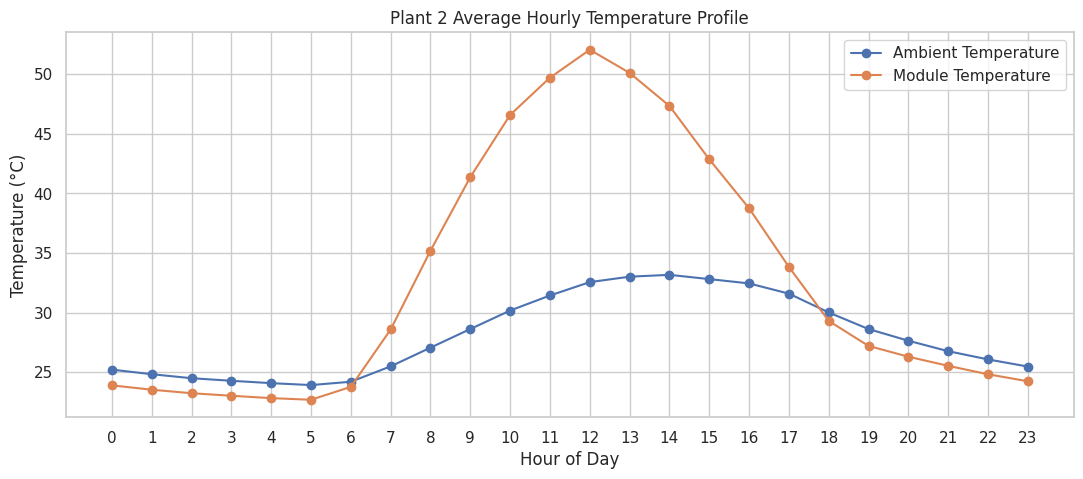

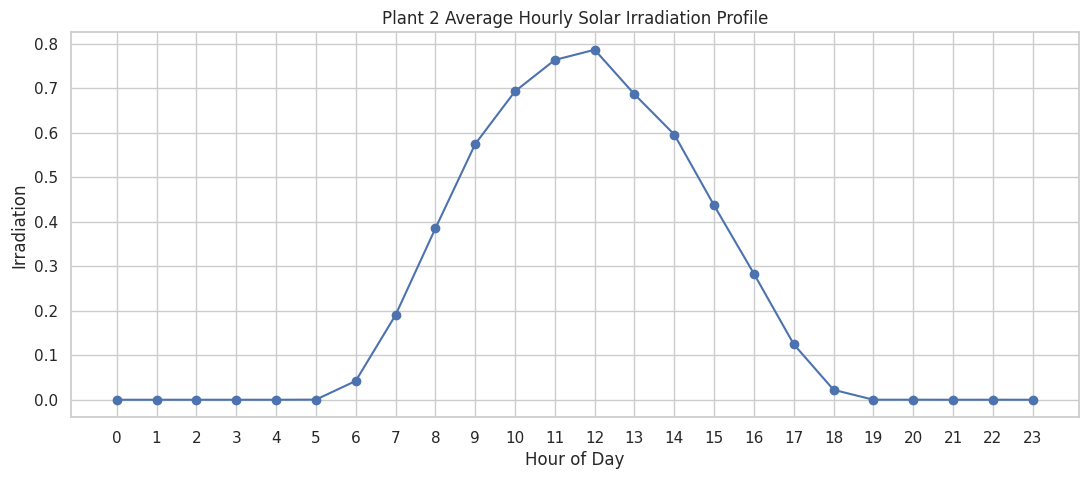

In [45]:
hourly_weather_profile = (
    weather.groupby("HOUR")
    .agg(
        ambient_temperature=("AMBIENT_TEMPERATURE","mean"),
        module_temperature=("MODULE_TEMPERATURE","mean"),
        irradiation=("IRRADIATION","mean")
    ).reset_index()
)

plt.figure(figsize=(13,5))
plt.plot(hourly_weather_profile["HOUR"], hourly_weather_profile["ambient_temperature"], marker="o", label="Ambient Temperature")
plt.plot(hourly_weather_profile["HOUR"], hourly_weather_profile["module_temperature"], marker="o", label="Module Temperature")
plt.title("Plant 2 Average Hourly Temperature Profile")
plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(13,5))
plt.plot(hourly_weather_profile["HOUR"], hourly_weather_profile["irradiation"], marker="o")
plt.title("Plant 2 Average Hourly Solar Irradiation Profile")
plt.xlabel("Hour of Day")
plt.ylabel("Irradiation")
plt.xticks(range(24))
plt.grid(True)
plt.show()


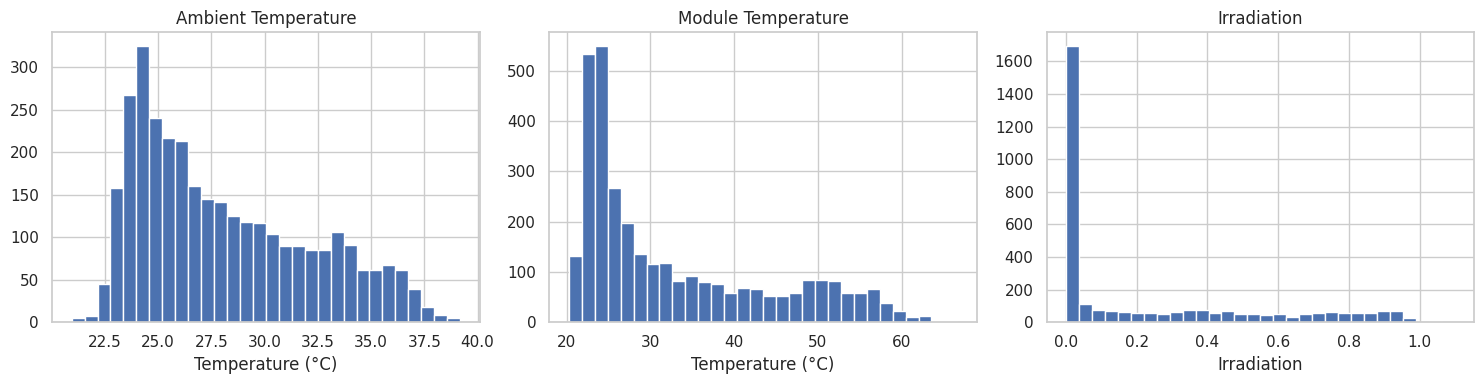

In [46]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
axes[0].hist(weather["AMBIENT_TEMPERATURE"].dropna(), bins=30)
axes[0].set_title("Ambient Temperature")
axes[0].set_xlabel("Temperature (°C)")
axes[1].hist(weather["MODULE_TEMPERATURE"].dropna(), bins=30)
axes[1].set_title("Module Temperature")
axes[1].set_xlabel("Temperature (°C)")
axes[2].hist(weather["IRRADIATION"].dropna(), bins=30)
axes[2].set_title("Irradiation")
axes[2].set_xlabel("Irradiation")
plt.tight_layout()
plt.show()


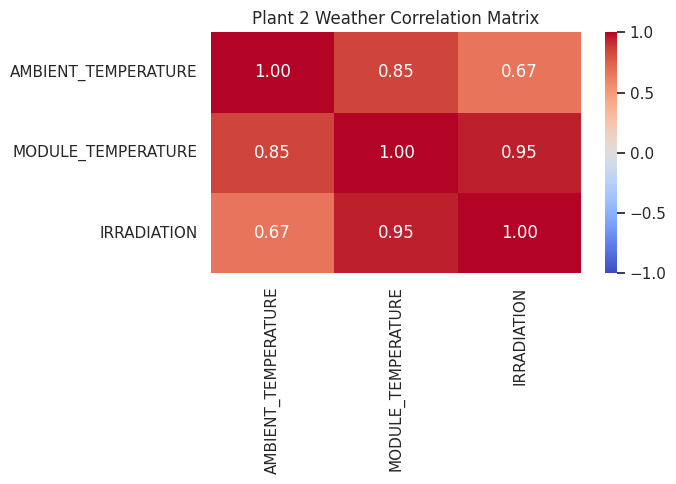

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
AMBIENT_TEMPERATURE,1.000000,0.847273,0.667639
MODULE_TEMPERATURE,0.847273,1.000000,0.946886
IRRADIATION,0.667639,0.946886,1.000000


In [47]:
weather_corr = weather[["AMBIENT_TEMPERATURE","MODULE_TEMPERATURE","IRRADIATION"]].corr()
plt.figure(figsize=(7,5))
sns.heatmap(weather_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Plant 2 Weather Correlation Matrix")
plt.tight_layout()
plt.show()
display(weather_corr)


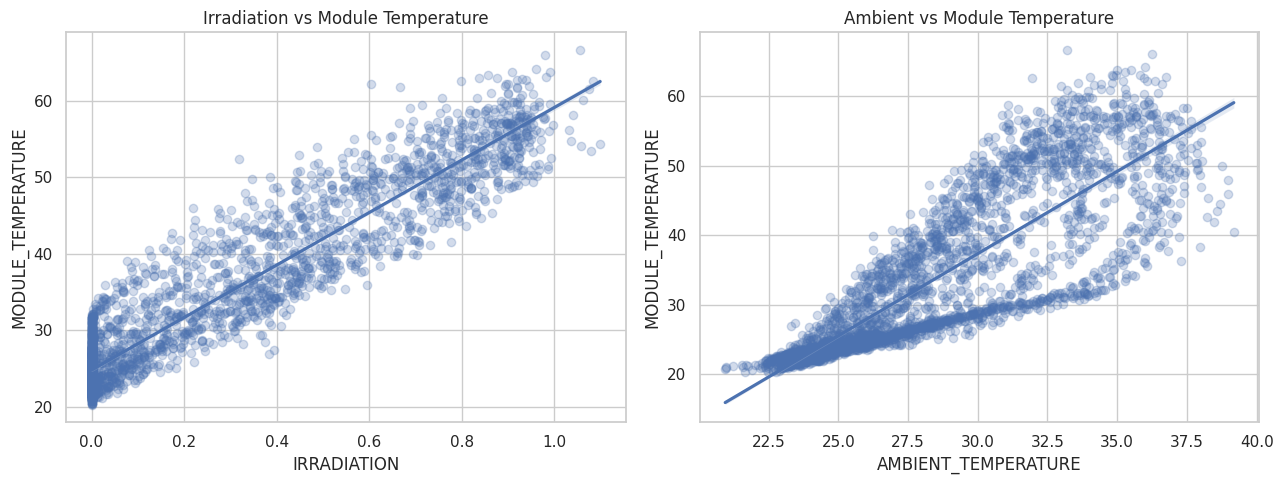

In [48]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
sns.regplot(data=weather, x="IRRADIATION", y="MODULE_TEMPERATURE", scatter_kws={"alpha":0.25}, ax=axes[0])
axes[0].set_title("Irradiation vs Module Temperature")
sns.regplot(data=weather, x="AMBIENT_TEMPERATURE", y="MODULE_TEMPERATURE", scatter_kws={"alpha":0.25}, ax=axes[1])
axes[1].set_title("Ambient vs Module Temperature")
plt.tight_layout()
plt.show()


## 8. Plant 2 Open-Meteo cleaning, mapping and EDA

**Correct project mapping:** Plant 2 uses `open-meteo-14.38N77.50E491m.csv`.

In [49]:
openmeteo = openmeteo_raw.copy()
openmeteo["time"] = pd.to_datetime(openmeteo["time"], errors="coerce")

openmeteo = openmeteo.rename(columns={
    "temperature_2m (°C)": "openmeteo_temperature",
    "relative_humidity_2m (%)": "humidity",
    "cloud_cover (%)": "cloud",
    "cloud_cover_low (%)": "cloud_low",
    "cloud_cover_mid (%)": "cloud_mid",
    "cloud_cover_high (%)": "cloud_high",
    "rain (mm)": "rain",
    "shortwave_radiation (W/m²)": "ghi",
    "direct_radiation (W/m²)": "direct_radiation",
    "diffuse_radiation (W/m²)": "dhi",
    "direct_normal_irradiance (W/m²)": "dni",
    "wind_speed_10m (km/h)": "wind_speed_10m"
})

print("Plant 2 Open-Meteo shape:", openmeteo.shape)
print("Date range:", openmeteo["time"].min(), "to", openmeteo["time"].max())
print("Missing values:")
display(openmeteo.isna().sum().to_frame("missing"))
display(openmeteo.head())


Plant 2 Open-Meteo shape: (816, 13)
Date range: 2020-05-15 00:00:00 to 2020-06-17 23:00:00
Missing values:


,missing
time,0
openmeteo_temperature,0
humidity,0
cloud,0
cloud_low,0
cloud_mid,0
cloud_high,0
rain,0
ghi,0
direct_radiation,0


,time,openmeteo_temperature,humidity,cloud,cloud_low,cloud_mid,cloud_high,rain,ghi,direct_radiation,dhi,dni,wind_speed_10m
0,2020-05-15 00:00:00,30.0,49,15,0,11,6,0.0,0.0,0.0,0.0,0.0,10.6
1,2020-05-15 01:00:00,29.3,52,16,0,7,10,0.0,0.0,0.0,0.0,0.0,7.1
2,2020-05-15 02:00:00,28.6,55,48,0,8,44,0.0,0.0,0.0,0.0,0.0,6.6
3,2020-05-15 03:00:00,28.0,56,79,0,6,78,0.0,0.0,0.0,0.0,0.0,5.6
4,2020-05-15 04:00:00,27.4,56,61,0,4,60,0.0,0.0,0.0,0.0,0.0,3.9


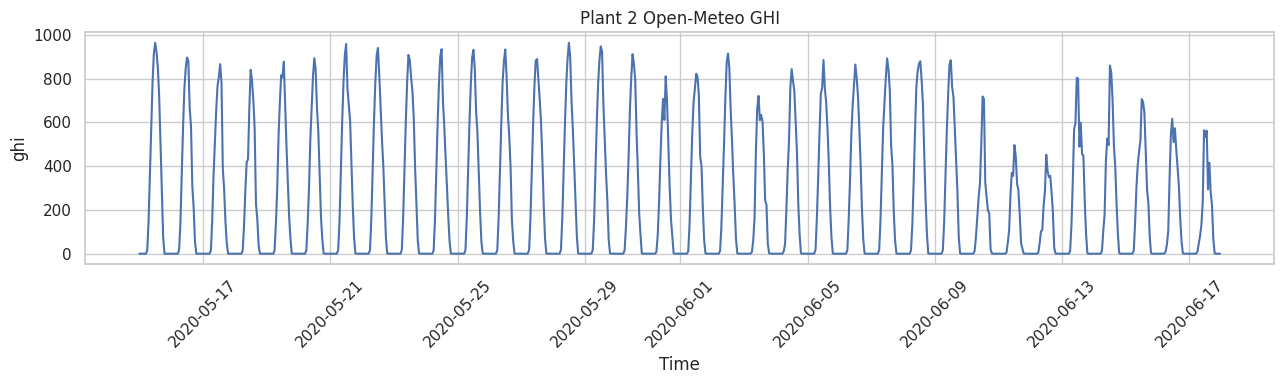

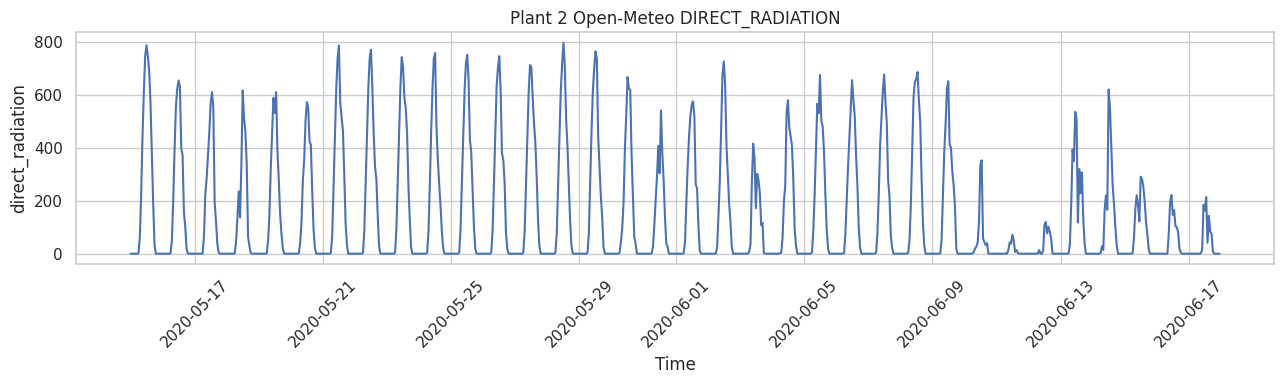

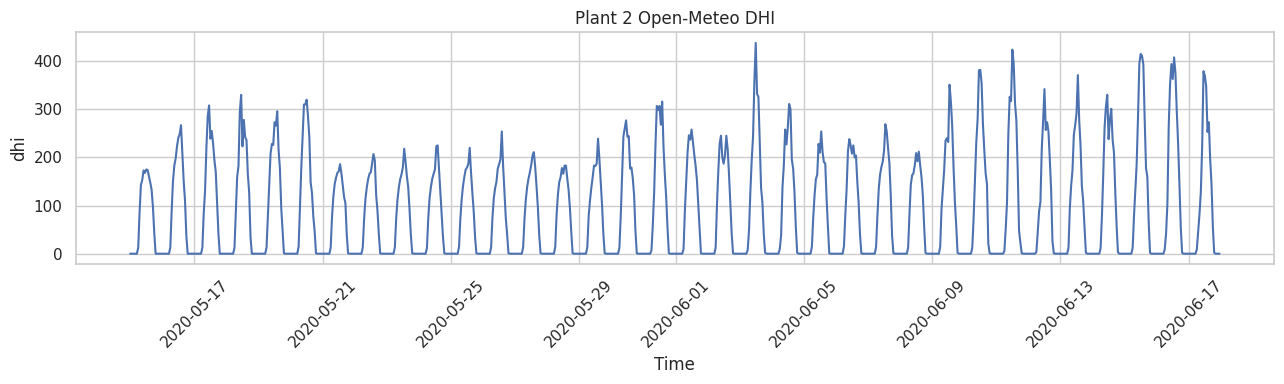

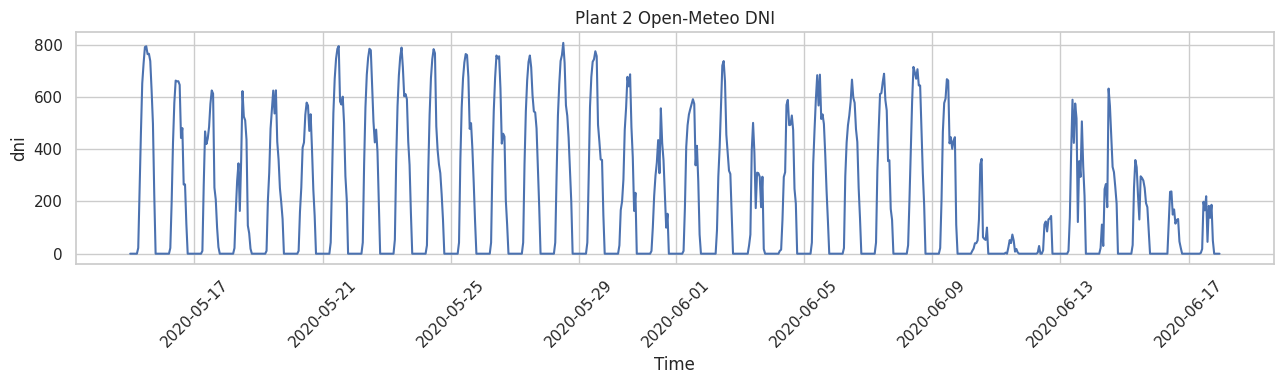

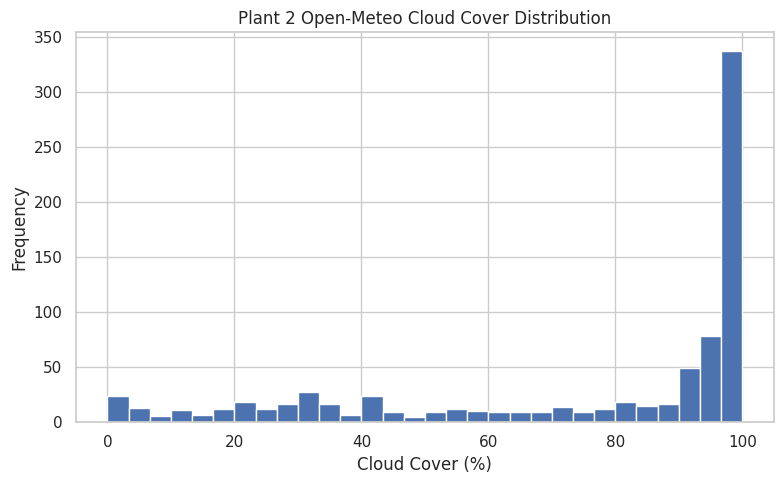

In [50]:
solar_cols = ["ghi","direct_radiation","dhi","dni"]
for col in solar_cols:
    if col in openmeteo.columns:
        plt.figure(figsize=(13,4))
        plt.plot(openmeteo["time"], openmeteo[col])
        plt.title(f"Plant 2 Open-Meteo {col.upper()}")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

plt.figure(figsize=(8,5))
plt.hist(openmeteo["cloud"].dropna(), bins=30)
plt.xlabel("Cloud Cover (%)")
plt.ylabel("Frequency")
plt.title("Plant 2 Open-Meteo Cloud Cover Distribution")
plt.tight_layout()
plt.show()


## 9. Generation–weather relationship using Plant 2 sensor data

Merged rows: 3259


,missing
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0
IRRADIATION,0


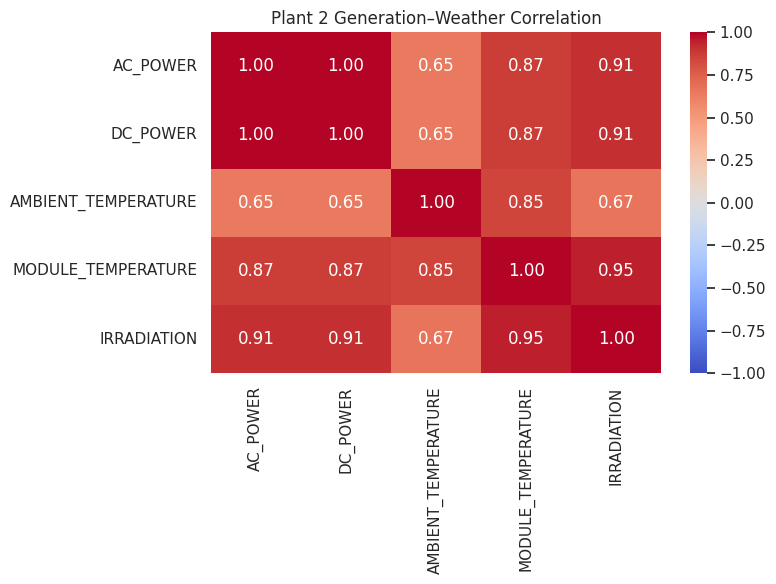

,AC_POWER,DC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
AC_POWER,1.000000,0.999996,0.648089,0.871927,0.911084
DC_POWER,0.999996,1.000000,0.648327,0.872469,0.911708
AMBIENT_TEMPERATURE,0.648089,0.648327,1.000000,0.847273,0.667639
MODULE_TEMPERATURE,0.871927,0.872469,0.847273,1.000000,0.946886
IRRADIATION,0.911084,0.911708,0.667639,0.946886,1.000000


In [51]:
generation_weather = pd.merge(
    plant_generation,
    weather[["DATE_TIME","AMBIENT_TEMPERATURE","MODULE_TEMPERATURE","IRRADIATION"]],
    on="DATE_TIME",
    how="left",
    validate="one_to_one"
)

print("Merged rows:", len(generation_weather))
display(generation_weather[["AMBIENT_TEMPERATURE","MODULE_TEMPERATURE","IRRADIATION"]].isna().sum().to_frame("missing"))

relationship_corr = generation_weather[
    ["AC_POWER","DC_POWER","AMBIENT_TEMPERATURE","MODULE_TEMPERATURE","IRRADIATION"]
].corr()

plt.figure(figsize=(8,6))
sns.heatmap(relationship_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Plant 2 Generation–Weather Correlation")
plt.tight_layout()
plt.show()
display(relationship_corr)


## 10. Final Member-4 integration — Plant 2 generation + weather + Open-Meteo

In [52]:
# Align sensor weather to every Plant 2 generation timestamp.
# Missing sensor timestamps are interpolated in time and explicitly flagged.
def weather_on_generation_timestamps(gen, weather_df):
    timestamps = pd.DataFrame({"DATE_TIME": sorted(gen["DATE_TIME"].dropna().unique())})
    w = weather_df.set_index("DATE_TIME")[
        ["AMBIENT_TEMPERATURE","MODULE_TEMPERATURE","IRRADIATION"]
    ].reindex(timestamps["DATE_TIME"])
    was_missing = w.isna().any(axis=1)
    w = w.interpolate(method="time", limit_direction="both").reset_index()
    w["sensor_weather_interpolated"] = was_missing.to_numpy()
    return w

weather_15 = weather_on_generation_timestamps(generation, weather)

print("Generation timestamps:", len(unique_generation_times))
print("Weather timestamps:", len(unique_weather_times))
print("Interpolated sensor-weather timestamps:", int(weather_15["sensor_weather_interpolated"].sum()))


Generation timestamps: 3259
Weather timestamps: 3259
Interpolated sensor-weather timestamps: 0


### Build integrated 15-minute inverter-level handoff

In [53]:
def add_openmeteo_asof(left, om):
    return pd.merge_asof(
        left.sort_values("time"),
        om.sort_values("time"),
        on="time",
        direction="backward",
        tolerance=pd.Timedelta("59min")
    )

def inverter_handoff(gen, sensor15, om):
    d = gen.rename(columns={"DATE_TIME":"time"})[
        ["time","PLANT_ID","SOURCE_KEY","DC_POWER","AC_POWER","DAILY_YIELD","TOTAL_YIELD"]
    ].rename(columns={
        "PLANT_ID":"plant_id",
        "SOURCE_KEY":"source_key",
        "DC_POWER":"dc_power",
        "AC_POWER":"ac_power",
        "DAILY_YIELD":"daily_yield",
        "TOTAL_YIELD":"total_yield"
    })
    w = sensor15.rename(columns={
        "DATE_TIME":"time",
        "AMBIENT_TEMPERATURE":"sensor_temperature",
        "MODULE_TEMPERATURE":"module_temperature",
        "IRRADIATION":"sensor_irradiation"
    })
    d = d.merge(w, on="time", how="left", validate="many_to_one")
    return add_openmeteo_asof(d, om)

plant2_ai_ml_15min = inverter_handoff(generation, weather_15, openmeteo)

print("Shape:", plant2_ai_ml_15min.shape)
print("Rows:", len(plant2_ai_ml_15min))
print("Columns:", plant2_ai_ml_15min.columns.tolist())


Shape: (67698, 23)
Rows: 67698
Columns: ['time', 'plant_id', 'source_key', 'dc_power', 'ac_power', 'daily_yield', 'total_yield', 'sensor_temperature', 'module_temperature', 'sensor_irradiation', 'sensor_weather_interpolated', 'openmeteo_temperature', 'humidity', 'cloud', 'cloud_low', 'cloud_mid', 'cloud_high', 'rain', 'ghi', 'direct_radiation', 'dhi', 'dni', 'wind_speed_10m']


### Build integrated 15-minute plant-level handoff

In [54]:
def plant_level_for_handoff(df):
    agg = (
        df.groupby("DATE_TIME", as_index=False)
        .agg(
            DC_POWER=("DC_POWER","sum"),
            AC_POWER=("AC_POWER","sum"),
            DAILY_YIELD=("DAILY_YIELD","sum"),
            INVERTER_COUNT=("SOURCE_KEY","nunique")
        )
        .sort_values("DATE_TIME")
        .reset_index(drop=True)
    )
    agg["PLANT_ID"] = int(df["PLANT_ID"].dropna().iloc[0])
    agg["AC_DC_EFFICIENCY"] = np.where(
        agg["DC_POWER"] > 0,
        agg["AC_POWER"] / agg["DC_POWER"],
        np.nan
    )
    agg["NEXT_INTERVAL_HOURS"] = (
        agg["DATE_TIME"].shift(-1).sub(agg["DATE_TIME"]).dt.total_seconds().div(3600)
    )
    agg.loc[agg.index[-1], "NEXT_INTERVAL_HOURS"] = 0.25
    agg["INTERVAL_VALID_FOR_ENERGY"] = agg["NEXT_INTERVAL_HOURS"].between(0,0.5)
    agg["AC_ENERGY_KWH_EST"] = np.where(
        agg["INTERVAL_VALID_FOR_ENERGY"],
        agg["AC_POWER"] * agg["NEXT_INTERVAL_HOURS"],
        np.nan
    )
    agg["DC_ENERGY_KWH_EST"] = np.where(
        agg["INTERVAL_VALID_FOR_ENERGY"],
        agg["DC_POWER"] * agg["NEXT_INTERVAL_HOURS"],
        np.nan
    )
    return agg

plant2_generation_integrated = plant_level_for_handoff(generation)

def plant_handoff(pl, sensor15, om):
    d = pl.rename(columns={
        "DATE_TIME":"time",
        "PLANT_ID":"plant_id",
        "DC_POWER":"dc_power",
        "AC_POWER":"ac_power",
        "DAILY_YIELD":"daily_yield",
        "INVERTER_COUNT":"inverter_count",
        "AC_DC_EFFICIENCY":"ac_dc_efficiency",
        "NEXT_INTERVAL_HOURS":"next_interval_hours",
        "INTERVAL_VALID_FOR_ENERGY":"interval_valid_for_energy",
        "AC_ENERGY_KWH_EST":"ac_energy_kwh_est",
        "DC_ENERGY_KWH_EST":"dc_energy_kwh_est"
    })
    w = sensor15.rename(columns={
        "DATE_TIME":"time",
        "AMBIENT_TEMPERATURE":"sensor_temperature",
        "MODULE_TEMPERATURE":"module_temperature",
        "IRRADIATION":"sensor_irradiation"
    })
    d = d.merge(w, on="time", how="left", validate="one_to_one")
    return add_openmeteo_asof(d, om)

plant2_ai_ml_15min_plantlevel = plant_handoff(
    plant2_generation_integrated, weather_15, openmeteo
)

print("Shape:", plant2_ai_ml_15min_plantlevel.shape)
display(plant2_ai_ml_15min_plantlevel.head())


Shape: (3259, 27)


,time,dc_power,ac_power,daily_yield,inverter_count,plant_id,ac_dc_efficiency,next_interval_hours,interval_valid_for_energy,ac_energy_kwh_est,...,cloud,cloud_low,cloud_mid,cloud_high,rain,ghi,direct_radiation,dhi,dni,wind_speed_10m
0,2020-05-15 00:00:00,0.0,0.0,48899.938095,22,4136001,NaN,0.25,True,0.0,...,15,0,11,6,0.0,0.0,0.0,0.0,0.0,10.6
1,2020-05-15 00:15:00,0.0,0.0,28401.000000,22,4136001,NaN,0.25,True,0.0,...,15,0,11,6,0.0,0.0,0.0,0.0,0.0,10.6
2,2020-05-15 00:30:00,0.0,0.0,28401.000000,22,4136001,NaN,0.25,True,0.0,...,15,0,11,6,0.0,0.0,0.0,0.0,0.0,10.6
3,2020-05-15 00:45:00,0.0,0.0,28401.000000,22,4136001,NaN,0.25,True,0.0,...,15,0,11,6,0.0,0.0,0.0,0.0,0.0,10.6
4,2020-05-15 01:00:00,0.0,0.0,26516.000000,22,4136001,NaN,0.25,True,0.0,...,16,0,7,10,0.0,0.0,0.0,0.0,0.0,7.1


## 11. Hourly AI/ML handoff — primary Week-1 dataset

In [55]:
def hourly_handoff(plant15):
    h = (
        plant15.set_index("time")
        .resample("1h")
        .agg(
            ac_power=("ac_power","mean"),
            dc_power=("dc_power","mean"),
            ac_energy_kwh_est=("ac_energy_kwh_est","sum"),
            dc_energy_kwh_est=("dc_energy_kwh_est","sum"),
            avg_inverter_count=("inverter_count","mean"),
            sensor_temperature=("sensor_temperature","mean"),
            module_temperature=("module_temperature","mean"),
            sensor_irradiation=("sensor_irradiation","mean"),
            openmeteo_temperature=("openmeteo_temperature","mean"),
            humidity=("humidity","mean"),
            cloud=("cloud","mean"),
            cloud_low=("cloud_low","mean"),
            cloud_mid=("cloud_mid","mean"),
            cloud_high=("cloud_high","mean"),
            rain=("rain","sum"),
            ghi=("ghi","mean"),
            direct_radiation=("direct_radiation","mean"),
            dhi=("dhi","mean"),
            dni=("dni","mean"),
            wind_speed_10m=("wind_speed_10m","mean")
        ).reset_index()
    )
    h.insert(1, "plant_id", int(plant15["plant_id"].dropna().iloc[0]))
    h["generation_data_complete"] = h["ac_power"].notna()
    return h

plant2_ai_ml_hourly = hourly_handoff(plant2_ai_ml_15min_plantlevel)

print("Hourly shape:", plant2_ai_ml_hourly.shape)
print("Incomplete generation hours:", int((~plant2_ai_ml_hourly["generation_data_complete"]).sum()))
display(plant2_ai_ml_hourly.head())


Hourly shape: (816, 23)
Incomplete generation hours: 0


,time,plant_id,ac_power,dc_power,ac_energy_kwh_est,dc_energy_kwh_est,avg_inverter_count,sensor_temperature,module_temperature,sensor_irradiation,...,cloud_low,cloud_mid,cloud_high,rain,ghi,direct_radiation,dhi,dni,wind_speed_10m,generation_data_complete
0,2020-05-15 00:00:00,4136001,0.0,0.0,0.0,0.0,22.0,26.767055,24.582656,0.0,...,0.0,11.0,6.0,0.0,0.0,0.0,0.0,0.0,10.6,True
1,2020-05-15 01:00:00,4136001,0.0,0.0,0.0,0.0,22.0,26.505909,25.172109,0.0,...,0.0,7.0,10.0,0.0,0.0,0.0,0.0,0.0,7.1,True
2,2020-05-15 02:00:00,4136001,0.0,0.0,0.0,0.0,22.0,26.296562,24.555514,0.0,...,0.0,8.0,44.0,0.0,0.0,0.0,0.0,0.0,6.6,True
3,2020-05-15 03:00:00,4136001,0.0,0.0,0.0,0.0,22.0,26.141691,24.627655,0.0,...,0.0,6.0,78.0,0.0,0.0,0.0,0.0,0.0,5.6,True
4,2020-05-15 04:00:00,4136001,0.0,0.0,0.0,0.0,22.0,25.509473,24.658230,0.0,...,0.0,4.0,60.0,0.0,0.0,0.0,0.0,0.0,3.9,True


## 12. Final AI/ML data-quality validation

In [56]:
def quality_row(name, df):
    ts = pd.to_datetime(df["time"], errors="coerce")
    intervals = ts.sort_values().diff().dt.total_seconds().div(60).dropna()
    return {
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "start": ts.min(),
        "end": ts.max(),
        "invalid_timestamps": int(ts.isna().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "duplicate_timestamps": int(ts.duplicated().sum()),
        "missing_cells": int(df.isna().sum().sum()),
        "median_interval_minutes": float(intervals.median()) if len(intervals) else np.nan
    }

quality = pd.DataFrame([
    quality_row("Plant 2 15-min inverter AI/ML", plant2_ai_ml_15min),
    quality_row("Plant 2 15-min plant AI/ML", plant2_ai_ml_15min_plantlevel),
    quality_row("Plant 2 hourly AI/ML", plant2_ai_ml_hourly)
])
display(quality)

validation_summary = pd.DataFrame([
    ["Plant 2", "15-min inverter rows", len(plant2_ai_ml_15min)],
    ["Plant 2", "15-min plant-level rows", len(plant2_ai_ml_15min_plantlevel)],
    ["Plant 2", "Hourly rows", len(plant2_ai_ml_hourly)],
    ["Plant 2", "15-min inverter columns", len(plant2_ai_ml_15min.columns)],
    ["Plant 2", "15-min plant-level columns", len(plant2_ai_ml_15min_plantlevel.columns)],
    ["Plant 2", "Hourly columns", len(plant2_ai_ml_hourly.columns)],
    ["Plant 2", "Interpolated sensor-weather timestamps", int(plant2_ai_ml_15min["sensor_weather_interpolated"].sum())],
    ["Plant 2", "TOTAL_YIELD > 1e9 rows", int((plant2_ai_ml_15min["total_yield"] > 1e9).sum())],
    ["Plant 2", "Incomplete hourly generation rows", int((~plant2_ai_ml_hourly["generation_data_complete"]).sum())]
], columns=["plant","check","value"])
display(validation_summary)


,dataset,rows,columns,start,end,invalid_timestamps,duplicate_rows,duplicate_timestamps,missing_cells,median_interval_minutes
0,Plant 2 15-min inverter AI/ML,67698,23,2020-05-15,2020-06-17 23:45:00,0,0,64439,0,0.0
1,Plant 2 15-min plant AI/ML,3259,27,2020-05-15,2020-06-17 23:45:00,0,0,0,1537,15.0
2,Plant 2 hourly AI/ML,816,23,2020-05-15,2020-06-17 23:00:00,0,0,0,0,60.0


,plant,check,value
0,Plant 2,15-min inverter rows,67698
1,Plant 2,15-min plant-level rows,3259
2,Plant 2,Hourly rows,816
3,Plant 2,15-min inverter columns,23
4,Plant 2,15-min plant-level columns,27
5,Plant 2,Hourly columns,23
6,Plant 2,Interpolated sensor-weather timestamps,0
7,Plant 2,TOTAL_YIELD > 1e9 rows,22296
8,Plant 2,Incomplete hourly generation rows,0


## 13. Final handoff exports

In [57]:
exports = {
    # AI/ML handoff datasets
    "plant2_ai_ml_handoff_15min.csv": plant2_ai_ml_15min,
    "plant2_ai_ml_handoff_15min_plantlevel.csv": plant2_ai_ml_15min_plantlevel,
    "plant2_ai_ml_handoff_hourly.csv": plant2_ai_ml_hourly,

    # Week-1 supporting outputs
    "plant2_cleaned_generation.csv": generation,
    "plant2_generation_final.csv": plant2_generation_integrated,
    "plant2_daily_generation_final.csv": daily_generation,
    "plant2_inverter_efficiency.csv": inverter_efficiency,
    "plant2_total_yield_anomalies.csv": anomaly_rows,
    "plant2_cleaned_weather.csv": weather,
    "plant2_weather_final.csv": weather_15,
    "plant2_hourly_weather_openmeteo_final.csv": plant2_ai_ml_hourly[
        ["time","sensor_temperature","module_temperature","sensor_irradiation",
         "openmeteo_temperature","humidity","cloud","cloud_low","cloud_mid",
         "cloud_high","rain","ghi","direct_radiation","dhi","dni","wind_speed_10m"]
    ],
    "plant2_validation_summary.csv": validation_summary,
    "plant2_data_quality_report.csv": quality
}

for filename, df in exports.items():
    df.to_csv(OUTPUT_DIR / filename, index=False)

print("Exported:")
for filename in sorted(exports):
    print(" -", filename)


Exported:
 - plant2_ai_ml_handoff_15min.csv
 - plant2_ai_ml_handoff_15min_plantlevel.csv
 - plant2_ai_ml_handoff_hourly.csv
 - plant2_cleaned_generation.csv
 - plant2_cleaned_weather.csv
 - plant2_daily_generation_final.csv
 - plant2_data_quality_report.csv
 - plant2_generation_final.csv
 - plant2_hourly_weather_openmeteo_final.csv
 - plant2_inverter_efficiency.csv
 - plant2_total_yield_anomalies.csv
 - plant2_validation_summary.csv
 - plant2_weather_final.csv


## 14. Final handover decision for AI/ML

### Recommended starting point
Use `plant2_ai_ml_handoff_hourly.csv` for the Week-1 baseline model.

### Higher-frequency plant model
Use `plant2_ai_ml_handoff_15min_plantlevel.csv` if the team wants 15-minute plant-wide forecasting.

### Advanced inverter-level model
Use `plant2_ai_ml_handoff_15min.csv` only when explicitly modeling inverter-level behavior. Repeated timestamps are expected because multiple inverters report simultaneously.

### Target
Use **`ac_power` / AC_POWER as the primary forecasting target**. Do not use `total_yield` as the primary target because Plant 2 contains a known anomaly in that source field.

### Continue from here
The AI/ML member can now add chronological train/validation/test splitting, time features, lag features, rolling irradiance, cloud features, baseline regression, and RMSE/MAPE evaluation below this section.

In [58]:
# Final automated completion check
expected = {
    "15-min inverter rows": len(plant2_ai_ml_15min) == 67698,
    "15-min plant rows": len(plant2_ai_ml_15min_plantlevel) == 3259,
    "hourly rows": len(plant2_ai_ml_hourly) == 816,
    "15-min inverter columns": len(plant2_ai_ml_15min.columns) == 23,
    "15-min plant columns": len(plant2_ai_ml_15min_plantlevel.columns) == 27,
    "hourly columns": len(plant2_ai_ml_hourly.columns) == 23,
    "all exports exist": all((OUTPUT_DIR / f).exists() for f in exports)
}
display(pd.DataFrame(expected.items(), columns=["check","result"]))
print("STATUS:", "PLANT 2 COMPLETE AI/ML HANDOFF READY" if all(expected.values()) else "CHECK REQUIRED")


,check,result
0,15-min inverter rows,True
1,15-min plant rows,True
2,hourly rows,True
3,15-min inverter columns,True
4,15-min plant columns,True
5,hourly columns,True
6,all exports exist,True


STATUS: PLANT 2 COMPLETE AI/ML HANDOFF READY


## 15. Interactive 3D Visualization

Let's create an interactive 3D visualization using Plotly to examine the relationship between our main environmental drivers (**Ambient Temperature**, **Module Temperature**, and **GHI**) and the target output (**AC Power**).

In [59]:
import plotly.express as px
import plotly.graph_objects as go

# Ensure we have non-null entries for visualization
vis_df = plant2_ai_ml_hourly.dropna(subset=['sensor_temperature', 'module_temperature', 'ghi', 'ac_power'])

fig = px.scatter_3d(
    vis_df,
    x='sensor_temperature',
    y='module_temperature',
    z='ghi',
    color='ac_power',
    color_continuous_scale='Viridis',
    labels={
        'sensor_temperature': 'Ambient Temp (°C)',
        'module_temperature': 'Module Temp (°C)',
        'ghi': 'GHI (W/m²)',
        'ac_power': 'AC Power (Avg)'
    },
    title='Plant 2: 3D Mapping of Generation vs. Weather Conditions'
)

fig.update_layout(
    scene=dict(
        xaxis_title='Ambient Temp (°C)',
        yaxis_title='Module Temp (°C)',
        zaxis_title='GHI (W/m²)'
    ),
    margin=dict(r=0, l=0, b=0, t=40)
)

fig.show()

## 16. Interactive 3D Visualization: Meteorological Drivers

Let's create a second interactive 3D plot, focusing on the Open-Meteo meteorological variables (**Forecasted Temperature**, **Cloud Cover**, and **GHI**) and how they relate to the target **AC Power**.

In [60]:
import plotly.express as px

# Ensure we have non-null entries for visualization
vis_df2 = plant2_ai_ml_hourly.dropna(subset=['openmeteo_temperature', 'cloud', 'ghi', 'ac_power'])

fig2 = px.scatter_3d(
    vis_df2,
    x='openmeteo_temperature',
    y='cloud',
    z='ghi',
    color='ac_power',
    color_continuous_scale='Turbo',
    labels={
        'openmeteo_temperature': 'Open-Meteo Temp (°C)',
        'cloud': 'Cloud Cover (%)',
        'ghi': 'GHI (W/m²)',
        'ac_power': 'AC Power (Avg)'
    },
    title='Plant 2: 3D Mapping of Generation vs. Open-Meteo Forecast Metrics'
)

fig2.update_layout(
    scene=dict(
        xaxis_title='Open-Meteo Temp (°C)',
        yaxis_title='Cloud Cover (%)',
        zaxis_title='GHI (W/m²)'
    ),
    margin=dict(r=0, l=0, b=0, t=40)
)

fig2.show()